# Scoring the Youth Mental Health Map Dimensions

This notebook explains how to calculate scores for each of the four Youth Mental Health Map dimensions from raw questionnaire data using R.

**Dimensions:**

1. Uncontrollable thinking patterns  
2. Re-experiencing difficult events  
3. Rigid high standards  
4. Emotional agency

The script assumes that you have item-level responses and demonstrates how to: 

- Compute scores for each dimension
- Plot scores to show distribution
  

Here we're using data from Smith et al (2025), which is available here.

### Load data

In [6]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Load your dataset (replace with actual filename)
df <- read.csv("YMHM_data.csv")


# Subset YMHM item responses (replace with YMHM item names)
ymhm_df <- df %>% 
    dplyr::select('YMHM_1':'YMHM_34') %>%
    mutate(across(everything(), as.numeric)) 

# Preview
head(ymhm_df)


,YMHM_1,YMHM_2,YMHM_3,YMHM_4,YMHM_5,YMHM_6,YMHM_7,YMHM_8,YMHM_9,YMHM_10,⋯,YMHM_25,YMHM_26,YMHM_27,YMHM_28,YMHM_29,YMHM_30,YMHM_31,YMHM_32,YMHM_33,YMHM_34
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2,1,3,2,2,3,1,3,5,4,⋯,2,1,1,2,2,4,2,3,2,3
2,2,1,2,2,1,1,1,3,4,3,⋯,4,2,2,4,2,2,2,4,5,1
3,2,1,1,2,2,1,1,2,4,2,⋯,2,2,2,4,3,3,3,4,2,3
4,2,3,3,3,2,4,2,4,4,4,⋯,2,2,2,3,4,3,4,3,2,1
5,4,2,4,4,4,1,1,2,5,5,⋯,4,3,3,3,1,2,1,2,1,2
6,2,1,2,3,1,2,2,2,5,5,⋯,5,1,2,3,5,4,4,5,4,3


In [7]:
# Load factor weights
factor_weights <- read.csv("YMHM_factor_weights.csv")

# Drop question column
factor_weights <- factor_weights[,-1]

# Preview
head(factor_weights)

,uncontrollable_thinking,re.experiencing,rigid_standards,emotional_agency
,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.022206559,0.10945263,0.017620218,-0.039534922
2,-0.090080038,0.14129632,-0.009809125,0.007799192
3,-0.043244614,0.14985498,-0.014776884,-0.015292398
4,0.003612012,0.10235506,-0.018548183,-0.016248099
5,-0.052179109,0.13908715,0.007133750,0.029729577
6,0.012568493,0.08441585,-0.056384254,-0.025885659


### Score data
Here, we multiply each item by its corresponding factor weight, sum the weighted item scores, and add the model intercept to produce the final factor scores for each dimension.

In [8]:
# Separate weights and intercepts
weights <- factor_weights[1:34, ]
intercepts <- as.numeric(factor_weights[35, ])

# Multiply each item by its corresponding factor weight
scores <- as.matrix(ymhm_df) %*% as.matrix(weights)

# Add the model intercept
scores <- scores + matrix(intercepts, nrow = nrow(scores),
                                        ncol = length(intercepts), byrow = TRUE)

# Add column names
scores <- as.data.frame(scores)
colnames(scores) <- c('uncontrollable_thinking', 're-experiencing', 'rigid_standards', 'emotional_agency')

# Add IDs
scores$id <- df$id

# Preview
head(scores)

,uncontrollable_thinking,re-experiencing,rigid_standards,emotional_agency,id
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.6820999,-0.444299511,0.336687416,-2.3452242,BE003DO
2,-0.9215735,0.005090121,-0.006554904,-1.7049977,TI901HO
3,-2.0986359,0.170183438,-0.333048295,-1.7877551,EL901MA
4,0.3333875,0.639598638,-0.124354130,-1.4273772,CH678HO
5,0.4313656,0.286064657,1.148581558,0.7725877,TE678AA
6,-1.4794808,0.658068049,0.322639461,-2.4178168,CH890SW



### Plot scores
Next we plot the dimension distributions

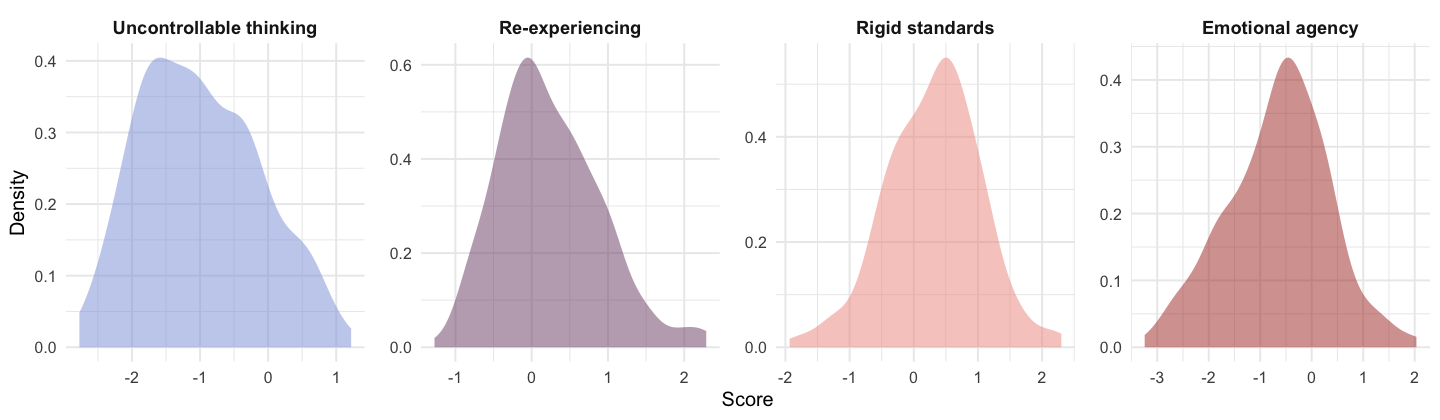

In [13]:
# Reshape to long format
scores_long <- scores %>%
  pivot_longer(
    cols = c("uncontrollable_thinking", "re-experiencing", "rigid_standards", "emotional_agency"),
    names_to = "dimension",
    values_to = "score"
  )

# Rename dimensions
scores_long$dimension <- factor(
  scores_long$dimension,
  levels = c("uncontrollable_thinking", "re-experiencing", "rigid_standards", "emotional_agency"),
  labels = c("Uncontrollable thinking", "Re-experiencing", "Rigid standards", "Emotional agency")
)

# Define colourblind friendly palette
colours <- c("#88a0dc", "#7c4b73", "#ed968c", "#ab3329")

# Plot with facets
options(repr.plot.width = 12, repr.plot.height = 3.5)

ggplot(scores_long, aes(x = score, fill = dimension)) +
  geom_density(alpha = 0.5, color = NA) +
  facet_wrap(~dimension, scales = "free", nrow = 1) +
  scale_fill_manual(values = colours) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 11, face = "bold"),
    panel.spacing = unit(1, "lines")
  ) +
  labs(x = "Score", y = "Density")


### Add scores to the original dataframe and save
Scores on the four YMHM dimensions can now be used for subsequent analyses

In [14]:
full_df <- merge(scores, df, by = "id")
write.csv(full_df, "full_df.csv")
head(full_df)

,id,uncontrollable_thinking,re-experiencing,rigid_standards,emotional_agency,YMHM_1,YMHM_2,YMHM_3,YMHM_4,YMHM_5,⋯,YMHM_25,YMHM_26,YMHM_27,YMHM_28,YMHM_29,YMHM_30,YMHM_31,YMHM_32,YMHM_33,YMHM_34
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1478047,0.009487362,-0.03748474,0.4579927,-0.57494575,1,2,1,1,3,⋯,1,2,2,4,2,4,2,3,2,1
2,408089936,0.052469820,-0.05558224,0.3669648,-2.14764314,2,1,2,1,3,⋯,4,1,1,4,2,4,2,3,4,4
3,AJ915CR,0.254466118,0.11297407,0.1498577,0.49516496,1,3,3,2,2,⋯,8,3,2,1,2,4,2,1,4,1
4,AL000FN,-0.900486206,-0.07517808,1.1546348,-0.03206869,2,2,2,3,2,⋯,4,2,2,2,2,3,2,2,2,3
5,AL033BO,-1.608402107,0.58472183,0.8332851,-0.42871448,2,4,2,2,3,⋯,3,2,2,4,3,2,5,2,2,3
6,AL101DE,-0.337533360,-0.01715221,0.6963300,-1.92176422,2,2,1,2,3,⋯,2,1,2,4,3,4,2,3,4,3
